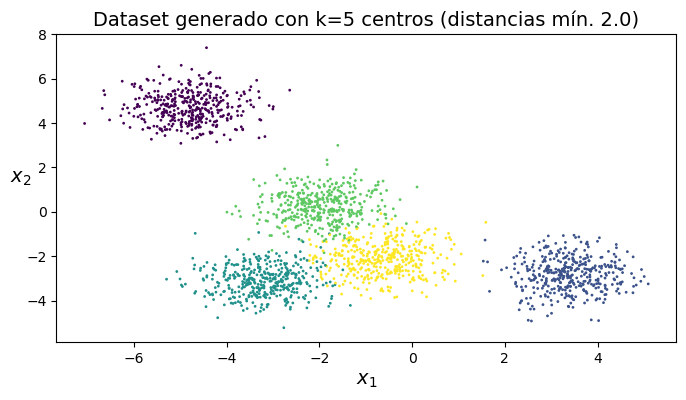

C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


Centros verdaderos:
 [[-4.79415506  4.69909852]
 [ 3.32442641 -2.87660889]
 [-3.18175033 -3.1659549 ]
 [-1.95757757  0.24756432]
 [-0.68054981 -2.0877086 ]]
Centros aprendidos:
 [[ 3.4007562  -2.8346028 ]
 [-0.6265757  -2.11289084]
 [-4.81320118  4.70708774]
 [-1.96998091  0.24936503]
 [-3.21818791 -3.12346993]]
Predicciones para X_new: [3 0 2 3]
Distancias a centros para X_new:
 [[5.91088208 4.16034472 5.5222486  2.63544068 6.05034524]
 [4.85118437 5.48342251 8.26888364 5.26929151 8.05703451]
 [8.66096241 5.63691367 2.49035079 2.93716395 6.12735587]
 [8.33232662 5.18766854 2.85638492 2.47513578 5.62770113]]


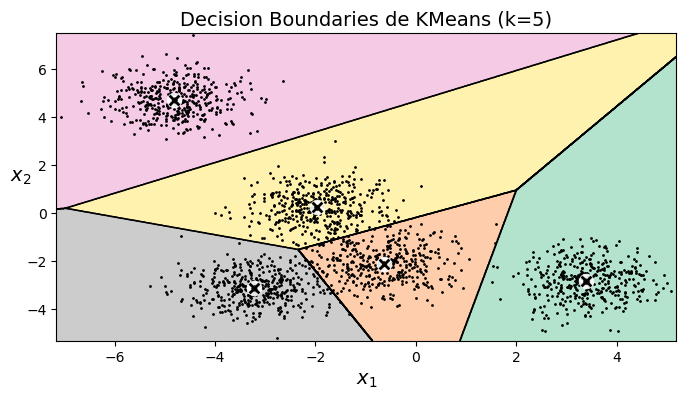

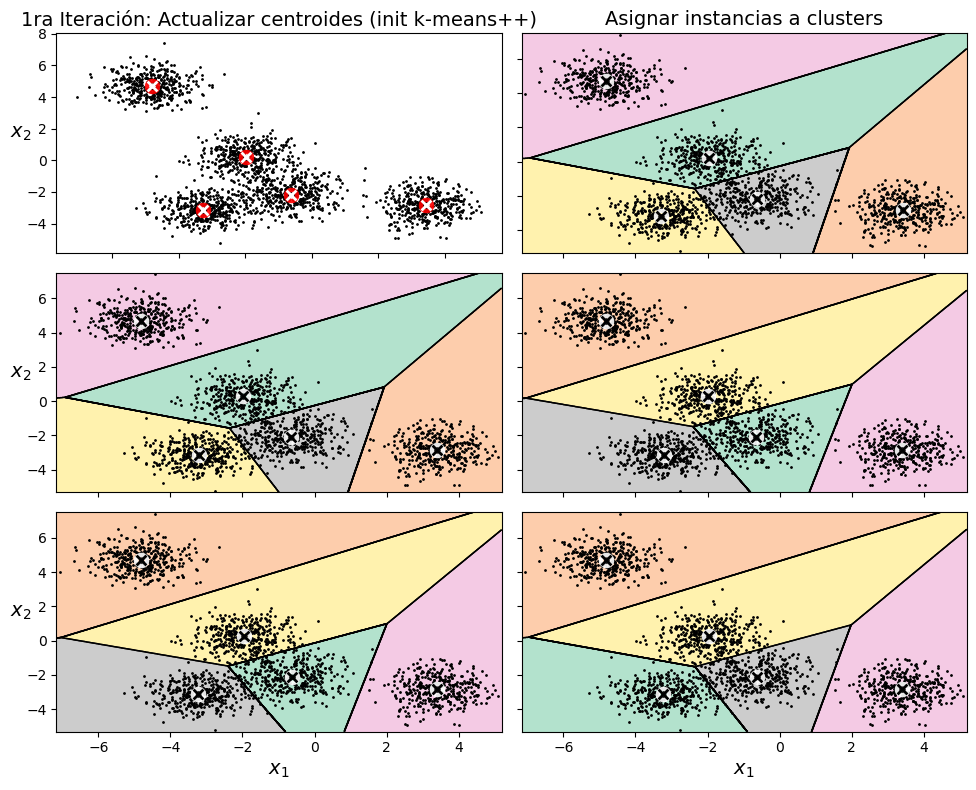

C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


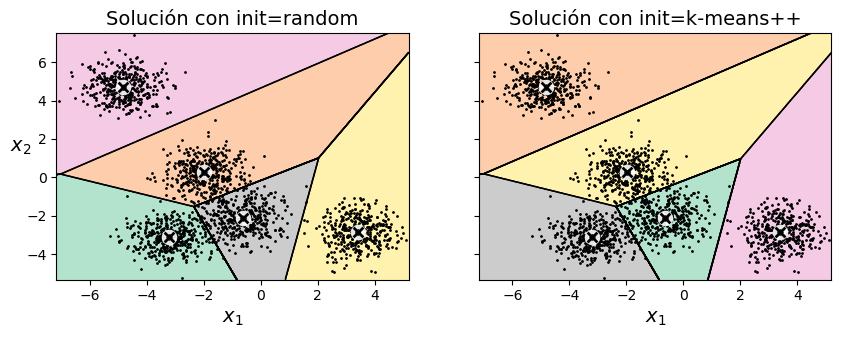

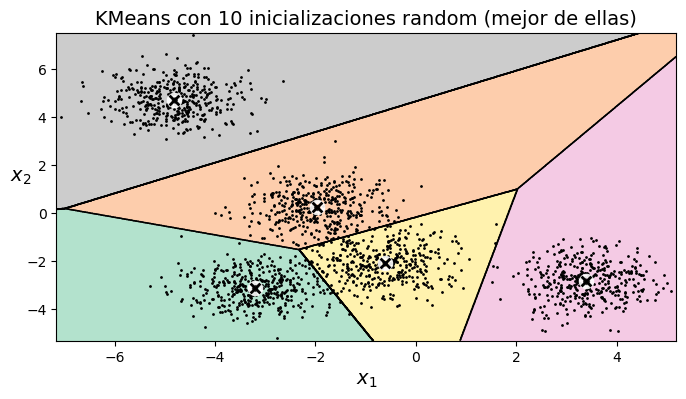

C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

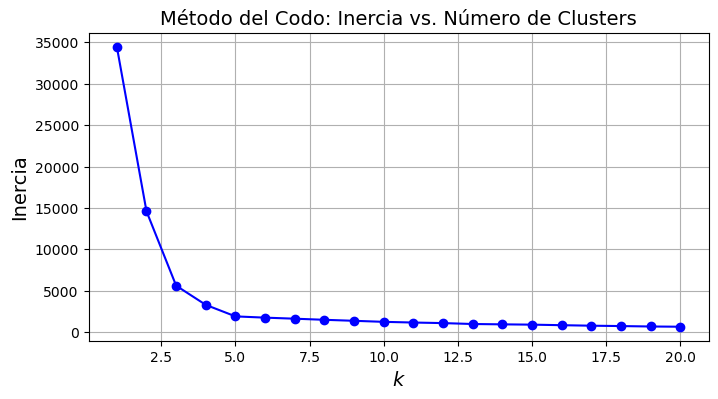

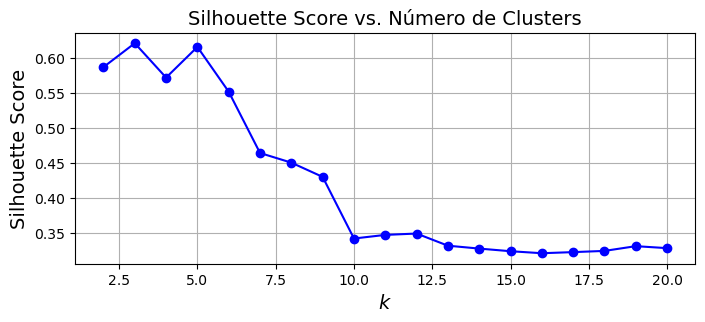

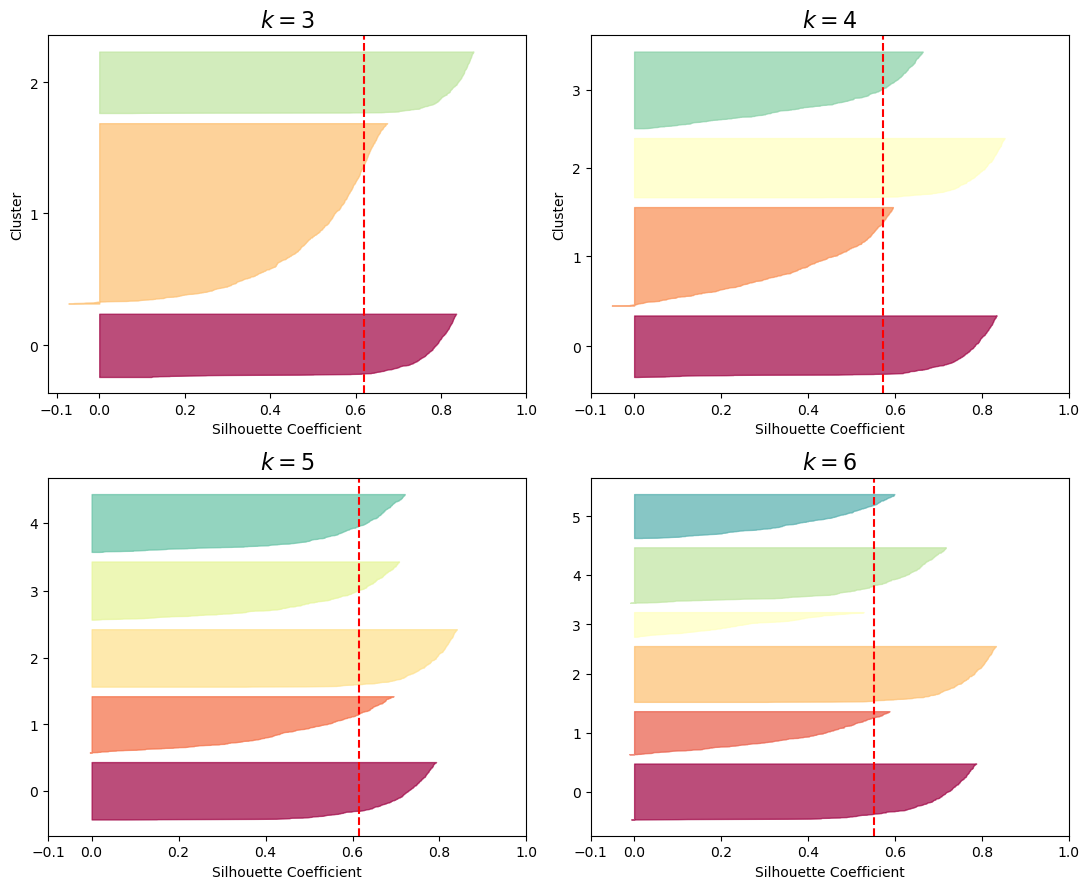

Silhouette score para k=5: 0.615


C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=2
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=2
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NU

Score de MiniBatchKMeans (k=5): -1913.723


In [2]:
# === IMPORTS ===
# Librerías base para datos, clustering y visualización
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator, FixedFormatter

# === SECCIÓN 1: GENERACIÓN DE DATOS (MODIFICADA PARA K VARIABLE Y DISTANCIAS) ===
# Función modificada: Genera blobs con k centros (1-20), asegurando distancias mínimas
# entre centros para verificación visual clara post-entrenamiento.
# - k: número de clusters/centros (1 <= k <= 20).
# - n_samples: total de puntos (default 2000).
# - min_distance: distancia mínima entre centros (default 2.0 para "importante distancia").
# Posible cambio: Ajustar min_distance o random_state para más variabilidad.
def generate_blobs(k, n_samples=2000, min_distance=2.0, random_state=42):
    if k < 1 or k > 20:
        raise ValueError("k debe estar entre 1 y 20.")
    
    np.random.seed(random_state)
    # Genera candidatos iniciales en un espacio amplio para dispersión
    attempts = 0
    while attempts < 100:  # Límite para evitar loops infinitos
        centers = np.random.uniform(-5, 5, (k, 2))  # Espacio amplio para distancias
        min_dist = np.min([np.linalg.norm(centers[i] - centers[j]) for i in range(k) for j in range(i+1, k)])
        if min_dist >= min_distance:
            break
        attempts += 1
    
    # Si no logra distancias, usa los generados (raro con espacio amplio)
    if attempts == 100:
        print(f"Advertencia: No se pudo asegurar distancia mínima exacta para k={k}. Usando aproximación.")
    
    # Std fijo para blobs redondeados y visibles
    blob_std = np.full(k, 0.7)  # Mayor std para blobs más grandes y visibles
    
    X, y = make_blobs(n_samples=n_samples, centers=centers, cluster_std=blob_std, random_state=random_state)
    return X, y, centers  # Retorna también centros verdaderos para verificación

# Ejemplo de uso (se usará más abajo)
k_example = 5  # Cambia esto para probar otros k (1-20)
X, y_true, true_centers = generate_blobs(k_example)

# Función de plot básico (fiel al original, con c=y_true para colorear verdaderos clusters)
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X, y_true)  # Muestra datos con clusters verdaderos para verificación visual
plt.title(f"Dataset generado con k={k_example} centros (distancias mín. 2.0)", fontsize=14)
plt.show()

# === SECCIÓN 2: AJUSTE BÁSICO DE KMEANS Y PREDICCIONES (ADAPTADO PARA K VARIABLE) ===
# Ajuste simple de KMeans para el k ejemplo
kmeans = KMeans(n_clusters=k_example, random_state=42)
y_pred = kmeans.fit_predict(X)

# Muestra centros aprendidos vs. verdaderos (para verificación de efectividad)
print("Centros verdaderos:\n", true_centers)
print("Centros aprendidos:\n", kmeans.cluster_centers_)

# Predicción para nuevos puntos (fiel al original)
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
print("Predicciones para X_new:", kmeans.predict(X_new))
print("Distancias a centros para X_new:\n", kmeans.transform(X_new))

# === SECCIÓN 3: FUNCIONES DE VISUALIZACIÓN (CASI INTACTAS, CON MEJORAS MÍNIMAS) ===
# Plots auxiliares (fieles al original)
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

# Visualización de boundaries para el modelo ajustado
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.title("Decision Boundaries de KMeans (k=5)", fontsize=14)
plt.show()

# === SECCIÓN 4: DEMOSTRACIÓN DE ITERACIONES (ADAPTADA PARA K VARIABLE) ===
# Muestra cómo converge KMeans en iteraciones (útil para efectividad).
# - Usa init="k-means++" por default (mejor que random).
# Posible cambio: Aumentar max_iter para datasets más grandes.
kmeans_iter1 = KMeans(n_clusters=k_example, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=1, random_state=4)  # Iter 1
kmeans_iter2 = KMeans(n_clusters=k_example, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=2, random_state=1)  # Iter 2
kmeans_iter3 = KMeans(n_clusters=k_example, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=5)  # Iter 3

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("1ra Iteración: Actualizar centroides (init k-means++)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Asignar instancias a clusters", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.tight_layout()
plt.show()

# === SECCIÓN 5: COMPARACIÓN DE INICIALIZACIONES (ÚTIL PARA MOSTRAR ESTABILIDAD) ===
# Compara random vs. k-means++ (demuestra por qué ++ es mejor para efectividad).
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

kmeans_rnd_init1 = KMeans(n_clusters=k_example, init="random", n_init=1,
                          algorithm="elkan", random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=k_example, init="k-means++", n_init=1,
                          algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solución con init=random", "Solución con init=k-means++")

plt.show()

# Múltiples inicializaciones para robustez
kmeans_rnd_10_inits = KMeans(n_clusters=k_example, init="random", n_init=10,
                             algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.title("KMeans con 10 inicializaciones random (mejor de ellas)", fontsize=14)
plt.show()

# === SECCIÓN 6: MÉTODO DEL CODO (AGREGADO PARA CUMPLIR EL PUNTO) ===
# Evalúa inercia (suma de distancias al centro) vs. k para encontrar "codo" óptimo.
# - max_k=20 como pide el punto.
# Posible cambio: Usar log-scale en y para datasets grandes.
max_k = 20
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 4))
plt.plot(range(1, max_k + 1), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo: Inercia vs. Número de Clusters", fontsize=14)
plt.grid(True)
# El "codo" visual se ve alrededor de k=5 (ajusta según datos)
plt.show()

# === SECCIÓN 7: SILHOUETTE SCORE (ADAPTADA PARA MÚLTIPLES K) ===
# Evalúa calidad de clusters midiendo cohesión/separación.
# - Plotea score vs. k.
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]
ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.title("Silhouette Score vs. Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

# Plot detallado de silhouette para k cercanos al óptimo (3-6, o hasta max_k)
plt.figure(figsize=(11, 9))
valid_ks = [k for k in (3, 4, 5, 6) if k <= max_k]  # Filtra si max_k <6

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in valid_ks[:2]:  # Solo en subplots izquierdos
        plt.ylabel("Cluster")

    if k in valid_ks:
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.tight_layout()
plt.show()

# Score para el k ejemplo (verificación)
print(f"Silhouette score para k={k_example}: {silhouette_score(X, kmeans.labels_):.3f}")

# === SECCIÓN 8: MINIBATCH KMEANS (OPCIONAL, COMENTADO PARA NO ALTERAR MUCHO) ===
# Versión eficiente para datasets grandes; aquí en blobs para demo.
# Posible cambio: Quitar si no es relevante, o integrar en elbow/silhouette.
from sklearn.cluster import MiniBatchKMeans

def load_next_batch(batch_size, X):  # Adaptado para pasar X
    return X[np.random.choice(len(X), batch_size, replace=False)]

# Ejemplo rápido (comenta si no lo necesitas)
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans_mini = None
for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k_example, init_size=init_size, random_state=init)
    X_init = load_next_batch(init_size, X)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size, X)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans_mini is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans_mini.sum_inertia_):
        best_kmeans_mini = minibatch_kmeans

print(f"Score de MiniBatchKMeans (k={k_example}): {best_kmeans_mini.score(X):.3f}")
# Para comparar: plt.figure(); plot_decision_boundaries(best_kmeans_mini, X); plt.show()